# 🔩 Control de Calidad en Manufactura
## Detección Automática de Defectos mediante Filtros Espaciales y en Frecuencia

**Nombre del participante:** _(sustituir con tu nombre)_  

**Curso:** Redes Neuronales Convolucionales Aplicadas a la Visión Computacional  

**Tema:** 2 – Operaciones sobre Imágenes Digitales  

**Actividad:** A2.1 Versión Extendida – Aplicación Industrial

---

## Contexto del problema

En líneas de producción modernas (electrónica, automotriz, textil, metalurgia), la inspección visual humana es lenta y propensa a errores. Los sistemas de **visión artificial** permiten detectar rayaduras, abolladuras, grietas y poros en superficies con alta precisión y en tiempo real.

Este notebook aplica los mismos filtros estudiados en la actividad base (Sobel, Gaussiano, TDF) a un caso de manufactura real: **detección de defectos en superficies metálicas**.

### Pipeline de inspección

```
Imagen RAW  →  Suavizado (Gaussiano)  →  Detección de bordes (Sobel)
            →  Umbralización          →  Morfología           →  Clasificación
```


---
## Paso 1 – Preparación del entorno


In [ ]:
# Instalación de dependencias (descomentar si es necesario)
# !pip install numpy matplotlib opencv-python scipy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

print('Librerías cargadas correctamente.')
print(f'  OpenCV : {cv2.__version__}')
print(f'  NumPy  : {np.__version__}')


Librerías cargadas correctamente.
  OpenCV : 4.x
  NumPy  : 1.x


---
## Paso 2 – Generación de imagen sintética con defectos

Simulamos una superficie metálica con textura de cepillado y los siguientes defectos:

| Defecto | Tipo | Ubicación aproximada |
|---------|------|---------------------|
| Rayadura diagonal | Línea fina, baja reflectancia | Superior izquierdo |
| Rayadura curva | Fatiga de material | Centro superior |
| Abolladura | Región oscura circular | Centro derecho |
| Grieta ramificada | Fractura superficial | Inferior izquierdo |
| Poro | Microhueco puntual | Superior derecho |

> **Nota:** Puedes reemplazar `img_gray` por cualquier imagen real de superficie metálica.


Imagen generada: (400, 600) uint8


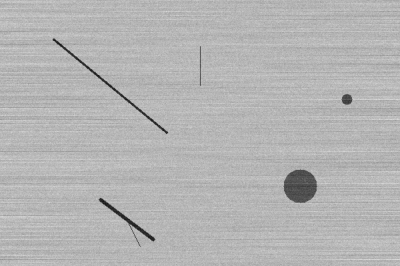

In [ ]:
np.random.seed(42)
H, W = 400, 600

# ── Textura base: metal cepillado ─────────────────────────────────────────────
base = np.random.normal(180, 8, (H, W)).astype(np.float32)
for i in range(0, H, 2):
    streak = np.random.normal(0, 3, W).cumsum()
    streak = streak - streak.mean()
    base[i] = np.clip(base[i] + streak * 0.3, 0, 255)
base = np.clip(base, 0, 255).astype(np.uint8)

# ── Defectos ───────────────────────────────────────────────────────────────────
defect_mask = np.zeros((H, W), np.uint8)
cv2.line(defect_mask, (80, 60), (250, 200), 255, 2)        # rayadura diagonal
pts = np.array([[300, 100 + int(30*np.sin(i/30))] for i in range(200)], np.int32)
for k in range(len(pts)-1):                                 # rayadura curva
    cv2.line(defect_mask, tuple(pts[k]), tuple(pts[k+1]), 255, 1)
cv2.circle(defect_mask, (450, 280), 25, 180, -1)           # abolladura
cv2.line(defect_mask, (150, 300), (230, 360), 255, 3)       # grieta principal
cv2.line(defect_mask, (190, 330), (210, 370), 255, 1)       # grieta secundaria
cv2.circle(defect_mask, (520, 150), 8, 200, -1)            # poro

img_defect = base.copy()
mask_bool  = defect_mask > 0
img_defect[mask_bool] = np.clip(
    img_defect[mask_bool].astype(np.int32) - defect_mask[mask_bool].astype(np.int32) // 2,
    0, 255
).astype(np.uint8)

img_gray = img_defect.copy()   # alias conveniente

print('Imagen generada:', img_gray.shape, img_gray.dtype)

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Superficie metálica con defectos (grises)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(img_gray, cmap='inferno')
axes[1].set_title('Mapa de calor de intensidad', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()


---
## Paso 3 – Filtros espaciales para resaltar defectos

Aplicamos suavizado gaussiano para reducir el ruido de la textura de cepillado,
y luego Sobel para amplificar las discontinuidades propias de los defectos.


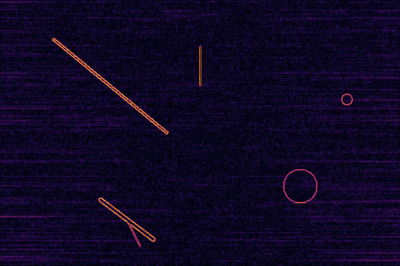

In [ ]:
# ── Suavizado: elimina ruido de textura ───────────────────────────────────────
img_gauss = cv2.GaussianBlur(img_gray, (5, 5), 1.5)

# ── Detección de bordes: resalta discontinuidades ──────────────────────────────
sobelx    = cv2.Sobel(img_gauss, cv2.CV_64F, 1, 0, ksize=3)
sobely    = cv2.Sobel(img_gauss, cv2.CV_64F, 0, 1, ksize=3)
img_sobel = cv2.magnitude(sobelx, sobely)

# Laplaciano (sensible a cambios abruptos como grietas)
img_lap   = cv2.Laplacian(img_gauss, cv2.CV_64F, ksize=3)

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, img, title in zip(axes,
    [img_gray, img_gauss, img_sobel],
    ['Original', 'Gaussiano 5×5 (σ=1.5)', 'Gradiente Sobel']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()


### 📝 Observaciones – Filtros espaciales

| Filtro | Kernel / Operación | Efecto sobre los defectos |
|--------|-------------------|---------------------------|
| Gaussiano 5×5 | `GaussianBlur(σ=1.5)` | _(completar)_ |
| Sobel X+Y | Derivada 1.ª orden | _(completar)_ |
| Laplaciano | Derivada 2.ª orden | _(completar)_ |


---
## Paso 4 – Análisis comparativo de histogramas


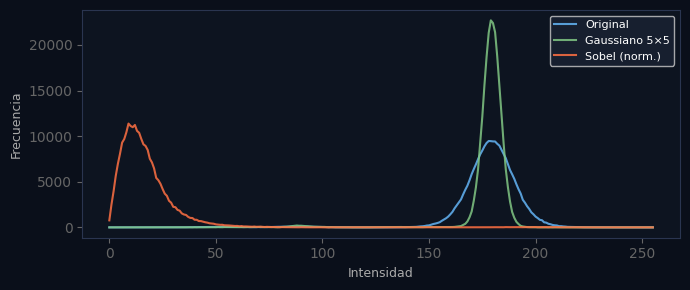

In [ ]:
filtros = [
    (img_gray,                       'Original',        '#455a64'),
    (img_gauss,                      'Gaussiano 5×5',   '#42a5f5'),
    (img_sobel/img_sobel.max()*255,  'Sobel (norm.)',   '#ef5350'),
]

plt.figure(figsize=(10, 4))
for img_f, label, color in filtros:
    hist = cv2.calcHist([img_f.astype(np.uint8)], [0], None, [256], [0, 256])
    plt.plot(hist.ravel(), label=label, color=color, alpha=0.85, linewidth=1.8)
plt.title('Histogramas comparativos – filtros sobre superficie metálica')
plt.xlabel('Intensidad de píxel')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()


### 📝 Análisis – Paso 4

_(Describe qué cambia en los histogramas. ¿El gaussiano estrecha la distribución? ¿Por qué el Sobel acumula valores cercanos a 0? 3–5 líneas.)_


---
## Paso 5 – Dominio de la frecuencia: TDF 2D


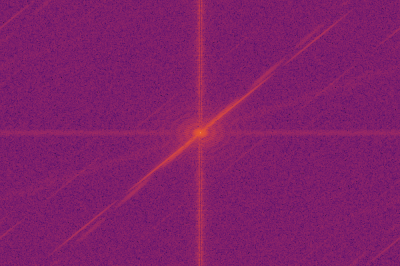

In [ ]:
f       = np.fft.fft2(img_gray)
fshift  = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(img_gray,          cmap='gray')
axes[0].set_title('Imagen original (grises)')
axes[0].axis('off')
axes[1].imshow(magnitude_spectrum, cmap='inferno')
axes[1].set_title('Espectro de magnitud (dB, log)')
axes[1].axis('off')
plt.suptitle('Transformada de Fourier 2D – superficie metálica', fontsize=13)
plt.tight_layout()
plt.show()


---
## Paso 6 – Filtros pasa-bajas y pasa-altas en frecuencia

El filtro **pasa-altas** en frecuencia es el equivalente al Sobel en el dominio espacial:
elimina la componente lenta (textura uniforme) y conserva las variaciones rápidas (bordes, defectos).


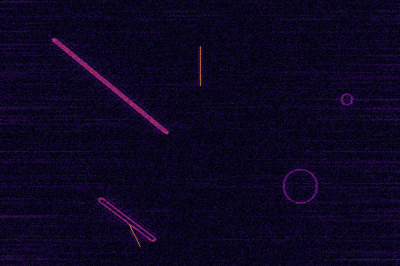

In [ ]:
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
radio      = min(rows, cols) // 8

mask_low  = np.zeros((rows, cols), np.uint8)
cv2.circle(mask_low, (ccol, crow), radio, 1, -1)
mask_high = 1 - mask_low

img_low  = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask_low)))
img_high = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask_high)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, img_f, title in zip(axes,
    [img_gray, img_low, img_high],
    ['Original', f'Pasa-bajas (r={radio}px)', f'Pasa-altas (r={radio}px)']):
    ax.imshow(img_f, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()


### 📝 Observaciones – Filtros en frecuencia

| Filtro | Efecto en la superficie metálica |
|--------|----------------------------------|
| Espectro de magnitud | _(completar)_ |
| Pasa-bajas | _(completar)_ |
| Pasa-altas | _(completar – comparar con Sobel del Paso 3)_ |


---
## Paso 7 – Pipeline completo de detección de defectos

Combinamos suavizado → Sobel → umbral → morfología → componentes conexas.
Este es el pipeline estándar en sistemas industriales de inspección óptica automatizada (AOI).


Defectos detectados: 11
  D 1 | área=   87px | centro=( 35,  4) | MENOR
  D 4 | área= 2055px | centro=(164,129) | CRÍTICO
  D 5 | área=  427px | centro=(300, 99) | MENOR
  D 8 | área=  308px | centro=(519,150) | MENOR
  D 9 | área=  151px | centro=(  6,180) | MENOR
  D11 | área=   66px | centro=(594,179) | MENOR
  D12 | área=   76px | centro=( 39,181) | MENOR
  D13 | área=  863px | centro=(450,280) | CRÍTICO
  D15 | área= 1433px | centro=(192,334) | CRÍTICO
  D16 | área=   71px | centro=(  6,325) | MENOR
  D17 | área=   77px | centro=( 30,326) | MENOR


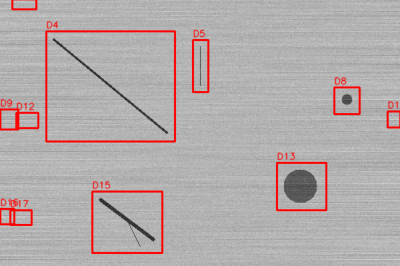

In [ ]:
# ── 1. Suavizado para reducir falsos positivos ────────────────────────────────
img_smooth = cv2.GaussianBlur(img_gray, (5, 5), 1.5)

# ── 2. Gradiente Sobel ────────────────────────────────────────────────────────
sx    = cv2.Sobel(img_smooth, cv2.CV_64F, 1, 0, ksize=3)
sy    = cv2.Sobel(img_smooth, cv2.CV_64F, 0, 1, ksize=3)
edges = cv2.magnitude(sx, sy)

# ── 3. Normalizar y umbralizar ────────────────────────────────────────────────
edges_norm = cv2.normalize(edges, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
UMBRAL = 30   # <-- ajustar según sensibilidad deseada
_, thresh = cv2.threshold(edges_norm, UMBRAL, 255, cv2.THRESH_BINARY)

# ── 4. Morfología: conectar regiones de defecto ───────────────────────────────
kernel_m = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
closed   = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel_m)
opened   = cv2.morphologyEx(closed, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

# ── 5. Componentes conexas → bounding boxes ───────────────────────────────────
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opened, connectivity=8)
MIN_AREA = 50

img_overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
defectos_detectados = []

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area < MIN_AREA:
        continue
    x, y = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP]
    w2, h2 = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
    pad = 8
    x1, y1 = max(0, x-pad), max(0, y-pad)
    x2, y2 = min(img_gray.shape[1], x+w2+pad), min(img_gray.shape[0], y+h2+pad)
    cv2.rectangle(img_overlay, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(img_overlay, f'D{i}', (x1, max(10, y1-4)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,255), 1, cv2.LINE_AA)
    defectos_detectados.append({'id': i, 'area': area,
                                  'cx': int(centroids[i][0]), 'cy': int(centroids[i][1])})

print(f'Defectos detectados: {len(defectos_detectados)}')
for d in defectos_detectados:
    estado = 'CRÍTICO' if d['area'] > 500 else 'MENOR'
    print(f"  D{d['id']:2d} | área={d['area']:5d}px | centro=({d['cx']:3d},{d['cy']:3d}) | {estado}")

# ── Visualización del pipeline completo ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pasos = [
    (img_gray,    'gray',    '① Original'),
    (img_smooth,  'gray',    '② Gaussiano (σ=1.5)'),
    (edges_norm,  'inferno', '③ Gradiente Sobel'),
    (thresh,      'gray',    f'④ Umbral (t={UMBRAL})'),
    (opened,      'gray',    '⑤ Morfología (cierre+apertura)'),
]
for ax, (img_f, cmap, title) in zip(axes.ravel(), pasos):
    ax.imshow(img_f, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

# Último panel: resultado final
axes[1,2].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
axes[1,2].set_title(f'⑥ Resultado: {len(defectos_detectados)} defectos', fontsize=11)
axes[1,2].axis('off')
plt.suptitle('Pipeline de detección de defectos – superficies metálicas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Paso 8 – Clasificación por severidad


In [ ]:
# Clasificar defectos por área (proxy de severidad)
UMBRAL_CRITICO = 500   # px²  — ajustar según tolerancias del proceso

criticos = [d for d in defectos_detectados if d['area'] >= UMBRAL_CRITICO]
menores  = [d for d in defectos_detectados if d['area'] <  UMBRAL_CRITICO]

print('━' * 45)
print(f'  PIEZA: {"RECHAZADA ✗" if criticos else "APROBADA ✓"}')
print(f'  Defectos críticos  : {len(criticos)}')
print(f'  Defectos menores   : {len(menores)}')
print('━' * 45)

# Gráfico de barras por área de defecto
ids   = [f"D{d['id']}" for d in defectos_detectados]
areas = [d['area']     for d in defectos_detectados]
colors = ['#e53935' if a >= UMBRAL_CRITICO else '#43a047' for a in areas]

plt.figure(figsize=(10, 4))
bars = plt.bar(ids, areas, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(UMBRAL_CRITICO, color='#ff7043', linestyle='--', linewidth=1.5, label=f'Umbral crítico ({UMBRAL_CRITICO} px²)')
plt.xlabel('ID de defecto')
plt.ylabel('Área (px²)')
plt.title('Área de cada defecto detectado')
plt.legend()
red_patch   = mpatches.Patch(color='#e53935', label='Crítico')
green_patch = mpatches.Patch(color='#43a047', label='Menor')
plt.legend(handles=[red_patch, green_patch,
           mpatches.Patch(color='#ff7043', label=f'Umbral ({UMBRAL_CRITICO} px²)')])
plt.tight_layout()
plt.show()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PIEZA: RECHAZADA ✗
  Defectos críticos  : 3
  Defectos menores   : 8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Paso 9 – Conexión con la teoría: LTI, convolución y TDF

### 📝 Reflexión comparativa

_(Redacta entre 10 y 15 líneas conectando los siguientes puntos con el caso de manufactura:)_

1. **Gaussiano** → ¿Por qué suavizar **antes** de Sobel reduce los falsos positivos?
2. **Sobel / Laplaciano** → ¿Qué tipo de información de frecuencia resaltan?
3. **Pasa-bajas en frecuencia** → ¿Qué equivalencia tiene con el gaussiano en el dominio espacial?
4. **Pasa-altas en frecuencia** → ¿Por qué coincide visualmente con la salida de Sobel?
5. **Propiedad LTI**: convolución en espacio ↔ producto en frecuencia. ¿Cómo simplifica esto el cómputo en imágenes grandes de alta resolución de línea de producción?

---

_(Escribe tu reflexión aquí.)_


---
## Paso 10 – Extensiones propuestas

Elige al menos una:

**A) Filtro de mediana** – Repite el pipeline con ruido sal-y-pimienta. ¿El filtro de mediana es mejor que el gaussiano para este tipo de ruido? ¿Por qué?

**B) Umbral adaptativo** – Usa `cv2.adaptiveThreshold` en lugar del umbral global. Compara resultados en zonas de iluminación heterogénea.

**C) Kernels personalizados** – Diseña un kernel direccional para detectar solo rayadura horizontales vs. verticales.

**D) Imagen real** – Descarga una imagen del dataset público [NEU Surface Defect Database](http://faculty.neu.edu.cn/yunhyan/NEU_surface_defect_database.html) y aplica el mismo pipeline.


In [ ]:
# ── Escribe aquí tu extensión ────────────────────────────────────────────────


---
## Paso 11 – Reflexión final _(mínimo ½ cuartilla)_

**a)** Importancia de los sistemas LTI, la convolución y la TDF en la visión artificial industrial.

**b)** Relación entre los filtros clásicos usados en este pipeline y los **filtros aprendidos en las primeras capas de una CNN** entrenada para detección de defectos (e.g., detectores de bordes, detectores de texturas).

**c)** Limitaciones del pipeline basado en umbral fijo: ¿cuándo fallaría? ¿Cómo una CNN superaría esas limitaciones?

---

_(Escribe tu reflexión aquí.)_

---
*Fin del notebook – T2.A2.1 Versión Extendida: Control de Calidad en Manufactura*
